# 02 — LightGBM Baseline · Iron and Silica Concentrate Prediction

Train one LightGBM regressor per target with full MLflow tracking:

1. Load gold features from notebook 01.
2. Temporal split (70% train, 15% val, 15% test).
3. Train independent LightGBM models for `% Iron Concentrate` and `% Silica Concentrate`.
4. Log params, metrics, model with signature in MLflow.
5. Compare against the naive baseline from notebook 00.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import warnings
from pathlib import Path

import mlflow
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))

from frothiq.data.loader import TARGET_COLS, temporal_split
from frothiq.features.pipeline import load_gold, list_feature_cols
from frothiq.models.baseline.lightgbm_model import train_one_target

mlflow.set_tracking_uri(f'file:{(ROOT / "mlruns").as_posix()}')
mlflow.set_experiment('frothiq-baseline')

C:\Users\jona2\frothiq\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026/05/02 17:33:55 INFO mlflow.tracking.fluent: Experiment with name 'frothiq-baseline' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:C:/Users/jona2/frothiq/mlruns/244440236091802954', creation_time=1777757635272, experiment_id='244440236091802954', last_update_time=1777757635272, lifecycle_stage='active', name='frothiq-baseline', tags={}, trace_location=None, workspace='default'>

## 1. Load gold features

In [2]:
gold = load_gold(ROOT / 'data' / 'processed' / 'gold.parquet')
feature_cols = list_feature_cols(gold, target_cols=TARGET_COLS)
print(f'Gold rows: {len(gold):,}')
print(f'Feature cols: {len(feature_cols)}')
print(f'Targets: {TARGET_COLS}')

Gold rows: 737,453
Feature cols: 309
Targets: ['pct_iron_concentrate', 'pct_silica_concentrate']


## 2. Temporal split

In [3]:
train, val, test = temporal_split(gold, train_frac=0.7, val_frac=0.15)
# Drop any rows with NaN in features (lag features create NaNs at the head).
train = train.dropna(subset=feature_cols + TARGET_COLS)
val = val.dropna(subset=feature_cols + TARGET_COLS)
test = test.dropna(subset=feature_cols + TARGET_COLS)
print(f'Train: {len(train):,}  Val: {len(val):,}  Test: {len(test):,}')

Train: 515,677  Val: 110,618  Test: 110,618


## 3. Train per-target models

In [4]:
results = {}
for target in TARGET_COLS:
    print(f'\n=== Training {target} ===')
    result = train_one_target(
        X_train=train[feature_cols],
        y_train=train[target].to_numpy(),
        X_val=val[feature_cols],
        y_val=val[target].to_numpy(),
        target_name=target,
        X_test=test[feature_cols],
        y_test=test[target].to_numpy(),
        run_name=f'lgbm-{target}',
    )
    results[target] = result
    print(f'val: {result.val_metrics}')
    print(f'test: {result.test_metrics}')


=== Training pct_iron_concentrate ===


2026/05/02 17:35:28 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


val: {'val_rmse': 0.9657296379413716, 'val_mae': 0.7560291157756028, 'val_r2': 0.03931781254491595}
test: {'test_rmse': 1.2160196729794812, 'test_mae': 0.9413833374363042, 'test_r2': -0.17087087334147544}

=== Training pct_silica_concentrate ===


2026/05/02 17:37:02 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


val: {'val_rmse': 0.9914629158054213, 'val_mae': 0.7510980667806735, 'val_r2': 0.08528585042559733}
test: {'test_rmse': 1.1520016772991488, 'test_mae': 0.9481351250594721, 'test_r2': 0.07589269888264438}


## 4. Comparison table vs naive baseline

In [5]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

rows = []
for target in TARGET_COLS:
    train_mean = train[target].mean()
    y_test = test[target].to_numpy()
    naive_pred = np.full_like(y_test, train_mean)
    naive_rmse = float(np.sqrt(mean_squared_error(y_test, naive_pred)))
    naive_mae = float(mean_absolute_error(y_test, naive_pred))

    rows.append({
        'target': target,
        'naive_rmse': naive_rmse,
        'naive_mae': naive_mae,
        'lgbm_rmse': results[target].test_metrics['test_rmse'],
        'lgbm_mae': results[target].test_metrics['test_mae'],
        'lgbm_r2': results[target].test_metrics['test_r2'],
    })
summary = pd.DataFrame(rows)
summary['rmse_improvement_pct'] = 100 * (1 - summary['lgbm_rmse'] / summary['naive_rmse'])
summary.round(3)

,target,naive_rmse,naive_mae,lgbm_rmse,lgbm_mae,lgbm_r2,rmse_improvement_pct
0,pct_iron_concentrate,1.236,0.950,1.216,0.941,-0.171,1.594
1,pct_silica_concentrate,1.203,0.993,1.152,0.948,0.076,4.267


## 5. Predicted vs true on test set

Visual sanity check.

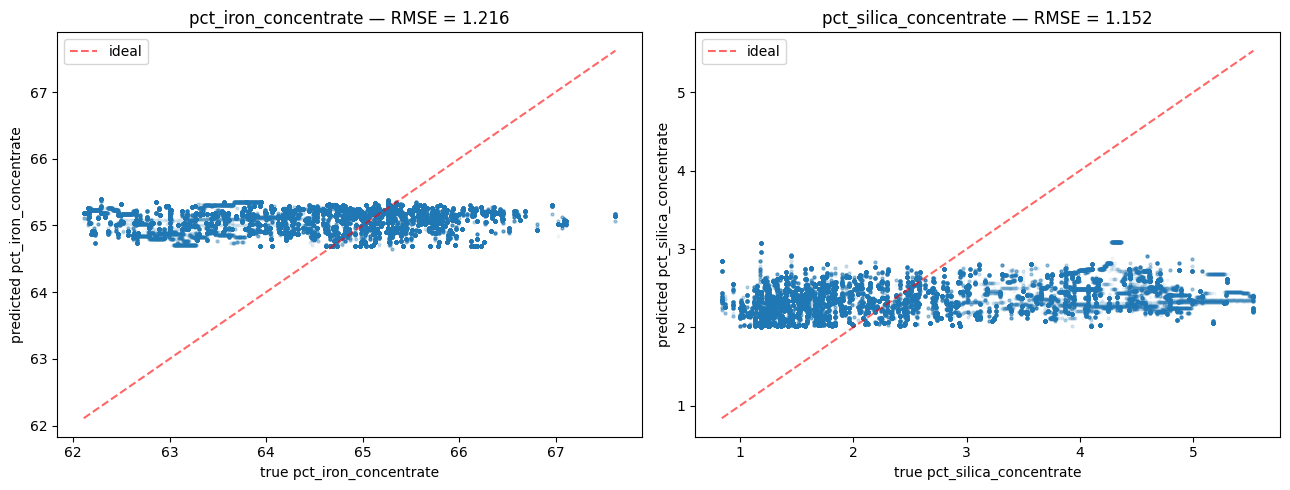

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, target in zip(axes, TARGET_COLS):
    y_pred = results[target].model.predict(test[feature_cols])
    y_true = test[target].to_numpy()
    ax.scatter(y_true, y_pred, alpha=0.05, s=4)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', alpha=0.6, label='ideal')
    ax.set_xlabel(f'true {target}')
    ax.set_ylabel(f'predicted {target}')
    ax.set_title(f'{target} — RMSE = {results[target].test_metrics["test_rmse"]:.3f}')
    ax.legend()
fig.tight_layout()

## 6. Top-20 feature importance

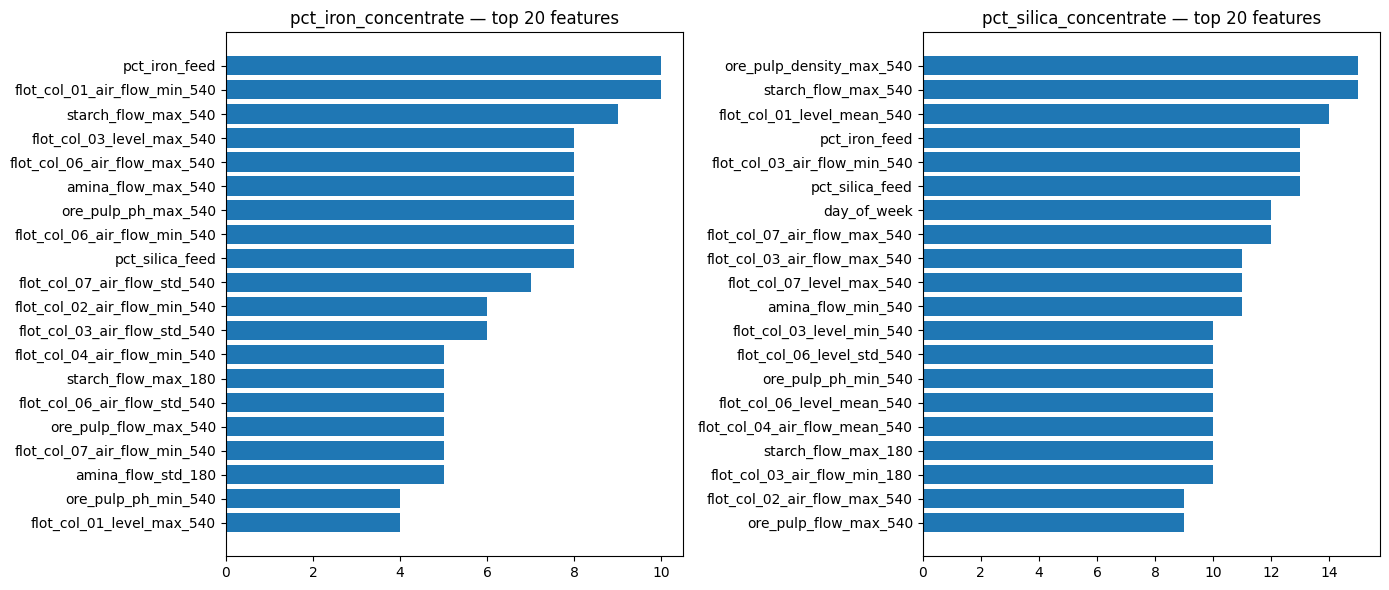

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, target in zip(axes, TARGET_COLS):
    model = results[target].model
    imp = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False).head(20)
    ax.barh(imp.index[::-1], imp.values[::-1])
    ax.set_title(f'{target} — top 20 features')
fig.tight_layout()

---

## What's next

- **Notebook 03** — LSTM (PyTorch) sequence model on raw sensor windows. Compare vs LightGBM.
- **Notebook 04** — SPC charts and Western Electric rules over the predicted residuals.
- **Notebook 05** — What-if simulator built into Streamlit dashboard.

## To inspect the runs

```bash
python -m mlflow ui --backend-store-uri ./mlruns
```

Then open http://localhost:5000.